# 订正脚本运行结果加载
读取run_predict.sh运行获得的nc文件，展示其中某一天的原始预测值、订正值及二者之间的差异。

## 1. 加载依赖与配置路径

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from netCDF4 import Dataset as NCDataset
from netCDF4 import num2date

# 路径配置
BASE_DIR = "/home/user3/scratch/SST Correction/CResUNet"
FORECAST_PATH = os.path.join(BASE_DIR, "data", "forecast_structured.nc")
OUTPUT_NC = os.path.join(BASE_DIR, "out", "forecast_corrected_structured.nc")

if not os.path.exists(OUTPUT_NC):
    raise FileNotFoundError(f"未找到输出 nc 文件: {OUTPUT_NC}")

def fmt_dt(dt):
    return f"{dt.year:04d}-{dt.month:02d}-{dt.day:02d} {dt.hour:02d}:{dt.minute:02d}"

# 选择输出文件中的 run/time
run_idx = 29
t = 119

## 2. 读取输出并提取单帧

In [2]:
with NCDataset(FORECAST_PATH, "r") as ds_fc, NCDataset(OUTPUT_NC, "r") as ds_out:
    # 若 predict.py 使用了时间子集过滤，输出 run 索引可能与原 forecast 不一致，这里按 start_time 对齐
    if "start_time" in ds_fc.variables and "start_time" in ds_out.variables:
        st_out = ds_out.variables["start_time"][run_idx]
        fc_start = ds_fc.variables["start_time"][:]
        fc_run_idx = int(np.where(fc_start == st_out)[0][0])
    else:
        fc_run_idx = run_idx

    forecast_map = ds_fc.variables["sst"][fc_run_idx, t]
    forecast_map = np.nan_to_num(forecast_map, nan=0.0)

    corrected_map = ds_out.variables["sst"][run_idx, t]
    corrected_map = np.nan_to_num(corrected_map, nan=0.0)

    # 不依赖 pred_bias 变量，直接由 forecast-corrected 计算 bias
    bias_map = forecast_map - corrected_map

    start_dt = None
    valid_dt = None

    if "start_time" in ds_out.variables:
        s = ds_out.variables["start_time"]
        if hasattr(s, "units"):
            calendar = getattr(s, "calendar", "standard")
            start_dt = num2date(s[run_idx], units=s.units, calendar=calendar)

    if "valid_time" in ds_out.variables:
        v = ds_out.variables["valid_time"]
        if hasattr(v, "units"):
            calendar = getattr(v, "calendar", "standard")
            valid_dt = num2date(v[run_idx, t], units=v.units, calendar=calendar)
            if start_dt is None:
                start_dt = num2date(v[run_idx, 0], units=v.units, calendar=calendar)

    pred_idx = t + 1
    if start_dt is not None and valid_dt is not None:
        time_label = f"Start {fmt_dt(start_dt)} | Forecast #{pred_idx} | Valid {fmt_dt(valid_dt)}"
    elif valid_dt is not None:
        time_label = f"Forecast #{pred_idx} | Valid {fmt_dt(valid_dt)}"
    else:
        time_label = f"Run {run_idx} | Forecast #{pred_idx}"

    land_mask = ds_fc.variables["land_mask"][:]
    ocean_mask = np.nan_to_num(land_mask, nan=0.0)

forecast_map[ocean_mask == 0] = np.nan
corrected_map[ocean_mask == 0] = np.nan
bias_map[ocean_mask == 0] = np.nan

field_vmin = np.nanmin(np.stack([forecast_map, corrected_map]))
field_vmax = np.nanmax(np.stack([forecast_map, corrected_map]))

bias_abs_max = np.nanmax(np.abs(bias_map))
if not np.isfinite(bias_abs_max) or bias_abs_max == 0:
    bias_abs_max = 0.1
bias_norm = TwoSlopeNorm(vmin=-bias_abs_max, vcenter=0.0, vmax=bias_abs_max)

## 3. 绘制订正结果对比

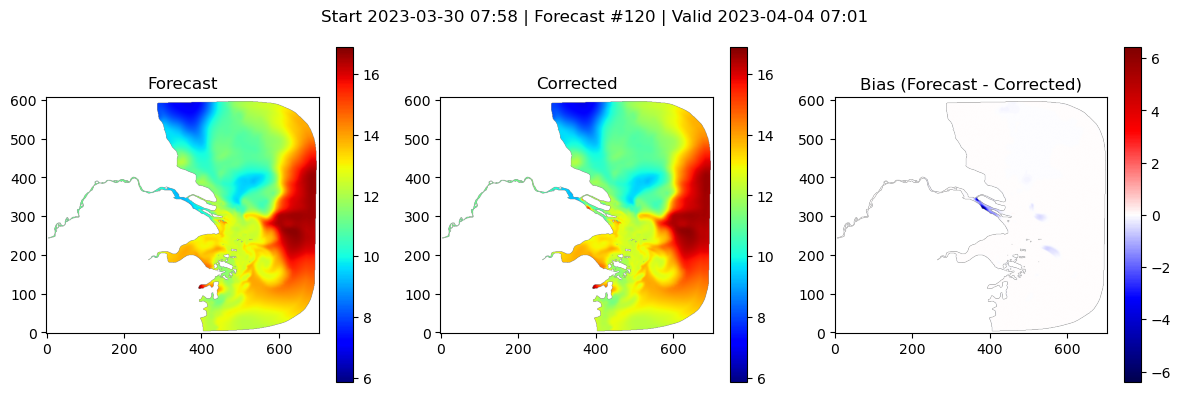

In [3]:
plt.figure(figsize=(12, 4))
plt.suptitle(time_label)

plt.subplot(1, 3, 1)
plt.title("Forecast")
plt.imshow(forecast_map, origin="lower", cmap="jet", vmin=field_vmin, vmax=field_vmax)
plt.colorbar()

plt.subplot(1, 3, 2)
plt.title("Corrected")
plt.imshow(corrected_map, origin="lower", cmap="jet", vmin=field_vmin, vmax=field_vmax)
plt.colorbar()

plt.subplot(1, 3, 3)
plt.title("Bias (Forecast - Corrected)")
plt.imshow(bias_map, origin="lower", cmap="seismic", norm=bias_norm)
plt.colorbar()

plt.tight_layout()
plt.show()

# SST 订正推理调试
训练完成后在 notebook 中加载 results 保存的模型，展示某一天的原始预测、订正结果与再分析数据的差异。

## 1. 加载依赖与配置路径

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset as NCDataset

from predict_utils import (
    correct_run_from_nc,
    visualize_run_step,
    compute_run_rmse,
    compute_yearly_error,
 )

# 路径配置
BASE_DIR = "/home/user3/scratch/SST Correction/CResUNet"
MODEL_PATH = os.path.join(BASE_DIR, "train_results", "best_model.pth")
FORECAST_PATH = os.path.join(BASE_DIR, "data", "forecast_structured.nc")
REANALYSIS_PATH = os.path.join(BASE_DIR, "data", "reanalysis_structured.nc")


## 2. 读取 results 中已保存的模型

In [2]:
print("Model path:", MODEL_PATH)
print("Forecast path:", FORECAST_PATH)
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError("未找到模型文件，请确认 train_results/best_model.pth 是否存在。")
if not os.path.exists(FORECAST_PATH):
    raise FileNotFoundError("未找到数据文件，请确认 data/forecast_structured.nc 是否存在。")

Model path: /home/user3/scratch/SST Correction/CResUNet/train_results/best_model.pth
Forecast path: /home/user3/scratch/SST Correction/CResUNet/data/forecast_structured.nc


## 3. 加载待订正数据

In [3]:
with NCDataset(FORECAST_PATH, "r") as ds:
    sst = ds.variables["sst"]
    land_mask = ds.variables["land_mask"][:]
    print("Forecast sst shape:", sst.shape)
    print("Land mask shape:", land_mask.shape)

Forecast sst shape: (360, 120, 608, 704)
Land mask shape: (608, 704)


## 4. 选择某一天并生成订正结果

In [4]:
# 选择某天的 run 索引
run_idx = 358

corrected_sst, pred_bias = correct_run_from_nc(
    model_path=MODEL_PATH,
    forecast_path=FORECAST_PATH,
    run_idx=run_idx,
    device="cuda"
 )

print("corrected_sst shape:", corrected_sst.shape)
print("pred_bias shape:", pred_bias.shape)

corrected_sst shape: (120, 608, 704)
pred_bias shape: (120, 608, 704)


## 5. 可视化订正前后对比

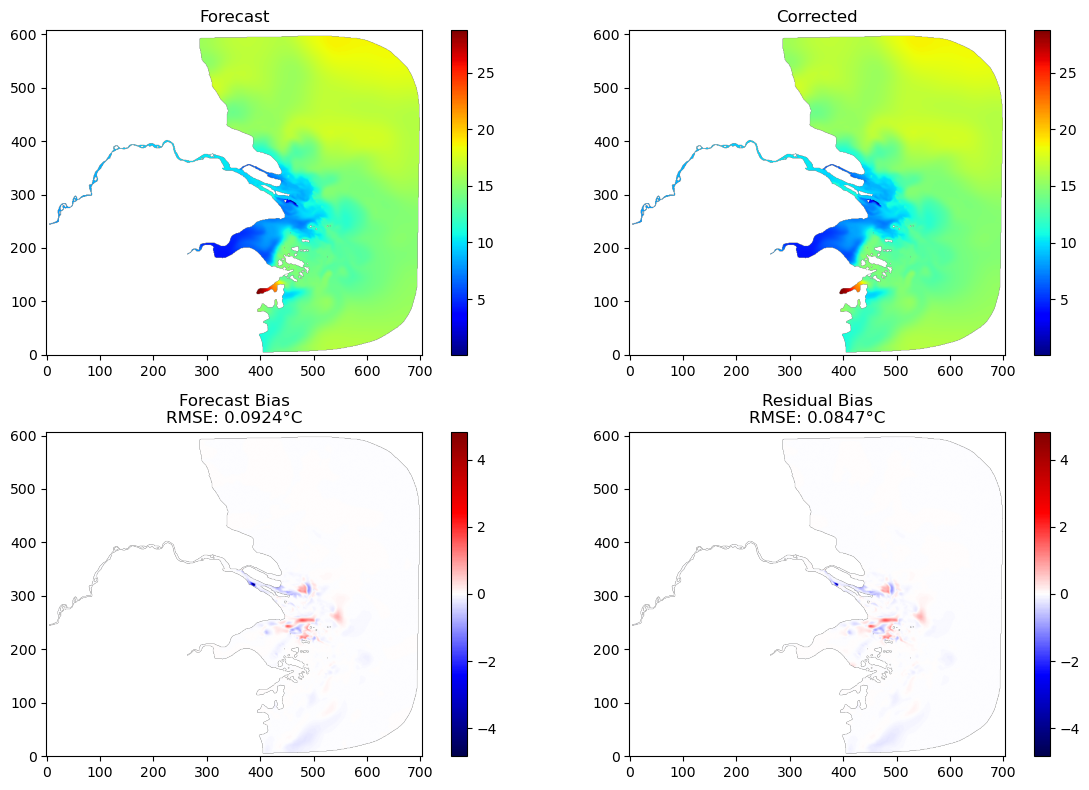

In [5]:
# 选一个时间步进行可视化
t = 47

visualize_run_step(
    forecast_path=FORECAST_PATH,
    reanalysis_path=REANALYSIS_PATH,
    run_idx=run_idx,
    t=t,
    corrected_sst=corrected_sst,
    pred_bias=pred_bias,
    mask_land=True,
 )

In [6]:
# 统计该天 120 小时 RMSE（Forecast vs Corrected）
rmse_forecast, rmse_corrected = compute_run_rmse(
    forecast_path=FORECAST_PATH,
    reanalysis_path=REANALYSIS_PATH,
    run_idx=run_idx,
    corrected_sst=corrected_sst,
 )

RMSE (Forecast): 0.06377°C
RMSE (Corrected): 0.06161°C


## 6. 全年误差对比（Forecast vs Corrected）

In [7]:
(rmse_fc, mae_fc), (rmse_corr, mae_corr) = compute_yearly_error(
    model_path=MODEL_PATH,
    forecast_path=FORECAST_PATH,
    reanalysis_path=REANALYSIS_PATH,
    device="cuda",
    mask_initial_steps=True,
 )

RMSE (Forecast): 0.21938 °C
MAE  (Forecast): 0.07953 °C
RMSE (Corrected): 0.20330 °C
MAE  (Corrected): 0.08016 °C
